In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dt = pd.read_csv('amazon.csv', encoding = "iso-8859-1", parse_dates=['date'])

In [5]:
dt.dtypes

year               int64
state                str
month                str
number           float64
date      datetime64[us]
dtype: object

In [3]:
dt.head(5)

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


In [5]:
dt.tail(5)

,year,state,month,number,date
6449,2012,Tocantins,Dezembro,128.0,2012-01-01
6450,2013,Tocantins,Dezembro,85.0,2013-01-01
6451,2014,Tocantins,Dezembro,223.0,2014-01-01
6452,2015,Tocantins,Dezembro,373.0,2015-01-01
6453,2016,Tocantins,Dezembro,119.0,2016-01-01


In [6]:
dt.shape
print("Number of Rows" , dt.shape[0])
print("Number of Columns" , dt.shape[1])

Number of Rows 6454
Number of Columns 5


In [7]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   year    6454 non-null   int64         
 1   state   6454 non-null   str           
 2   month   6454 non-null   str           
 3   number  6454 non-null   float64       
 4   date    6454 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 252.2 KB


In [8]:
dup_dt=dt.duplicated().any()

In [9]:
print(dup_dt)

True


In [10]:
dt=dt.drop_duplicates()

In [11]:
dt.shape

(6422, 5)

In [12]:
6454-6422

32

In [14]:
dt.isnull().sum()

year      0
state     0
month     0
number    0
date      0
dtype: int64

In [15]:
dt.describe(include='all')

,year,state,month,number,date
count,6422.000000,6422,6422,6422.000000,6422
unique,NaN,23,12,NaN,NaN
top,NaN,Rio,Agosto,NaN,NaN
freq,NaN,697,540,NaN,NaN
mean,2007.490969,NaN,NaN,108.815178,2007-06-29 10:46:40.622859
min,1998.000000,NaN,NaN,0.000000,1998-01-01 00:00:00
25%,2003.000000,NaN,NaN,3.000000,2003-01-01 00:00:00
50%,2007.000000,NaN,NaN,24.497000,2007-01-01 00:00:00
75%,2012.000000,NaN,NaN,114.000000,2012-01-01 00:00:00
max,2017.000000,NaN,NaN,998.000000,2017-01-01 00:00:00


In [21]:
dt['month'].unique()

<StringArray>
[  'Janeiro', 'Fevereiro',     'Março',     'Abril',      'Maio',     'Junho',
     'Julho',    'Agosto',  'Setembro',   'Outubro',  'Novembro',  'Dezembro']
Length: 12, dtype: str

In [23]:
dt['month_new']=dt['month'].map({'Janeiro':'jan',
                                    'Fevereiro':'feb',
                                    'Março':'march',
                                    'Abril':'april',
                                    'Maio':'may',
                                    'Junho':'jun',
                                    'Julho':'july',
                                    'Agosto':'august',
                                    'Setembro':'sep',
                                    'Outubro':'oct',
                                    'Novembro':'nov',
                                    'Dezembro':'dec'
                                   })

In [24]:
dt.head(3)

,year,state,month,number,date,month_new
0,1998,Acre,Janeiro,0.0,1998-01-01,jan
1,1999,Acre,Janeiro,0.0,1999-01-01,jan
2,2000,Acre,Janeiro,0.0,2000-01-01,jan


In [25]:
dt.shape

(6422, 6)

In [27]:
dt1= dt.groupby('month_new')['number'].sum().reset_index()
dt1

,month_new,number
0,april,28184.770
1,august,88050.435
2,dec,57535.480
3,feb,30839.050
4,jan,47681.844
5,july,92319.113
6,jun,55997.675
7,march,30709.405
8,may,34725.363
9,nov,85508.054


<Axes: xlabel='month_new', ylabel='number'>

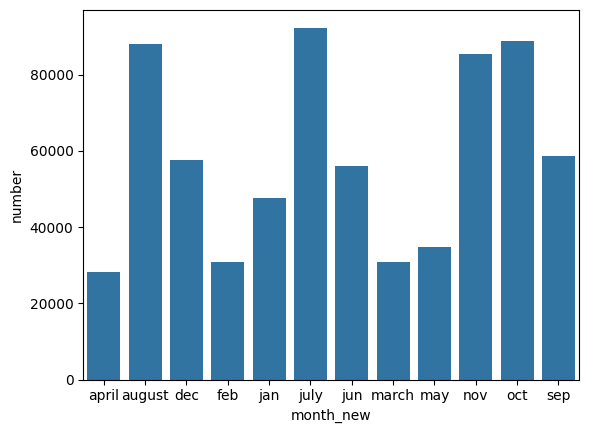

In [29]:
sns.barplot(x='month_new', y='number', data=dt1)

In [30]:
dt2= dt.groupby('year')['number'].sum().reset_index()
dt2

,year,number
0,1998,20013.971
1,1999,26882.821
2,2000,27351.251
3,2001,29054.612
4,2002,37390.600
5,2003,42760.674
6,2004,38450.163
7,2005,35004.965
8,2006,33824.161
9,2007,33028.413


<Axes: xlabel='year', ylabel='number'>

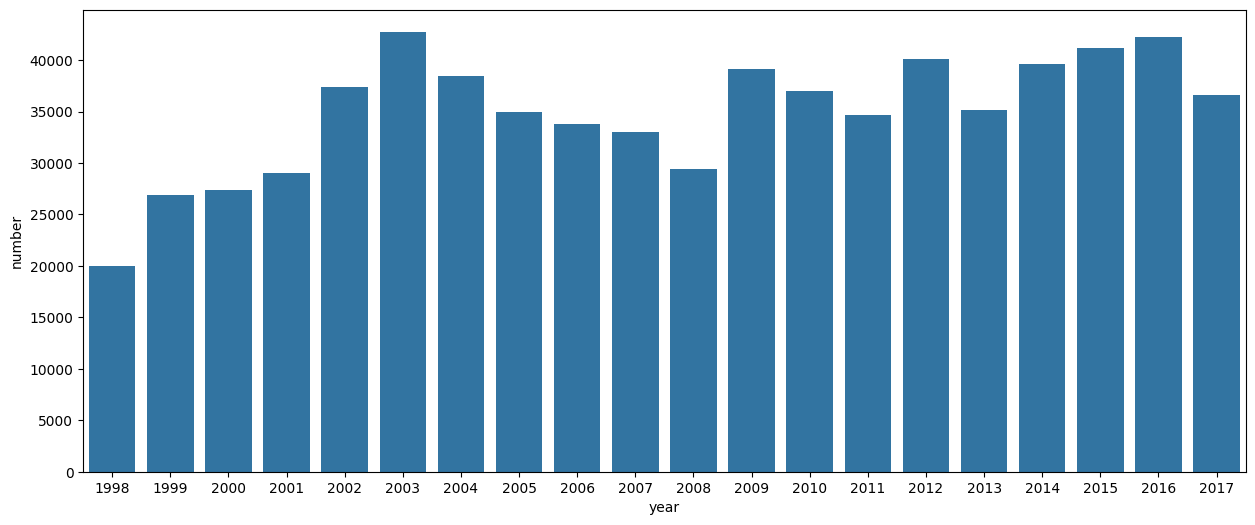

In [34]:
plt.figure(figsize=(15,6))
sns.barplot(x='year', y='number', data=dt2)

In [35]:
dt3= dt.groupby('state')['number'].sum().reset_index()
dt3

,state,number
0,Acre,18464.030
1,Alagoas,4606.000
2,Amapa,21831.576
3,Amazonas,30650.129
4,Bahia,44746.226
5,Ceara,30428.063
6,Distrito Federal,3561.000
7,Espirito Santo,6546.000
8,Goias,37695.520
9,Maranhao,25129.131


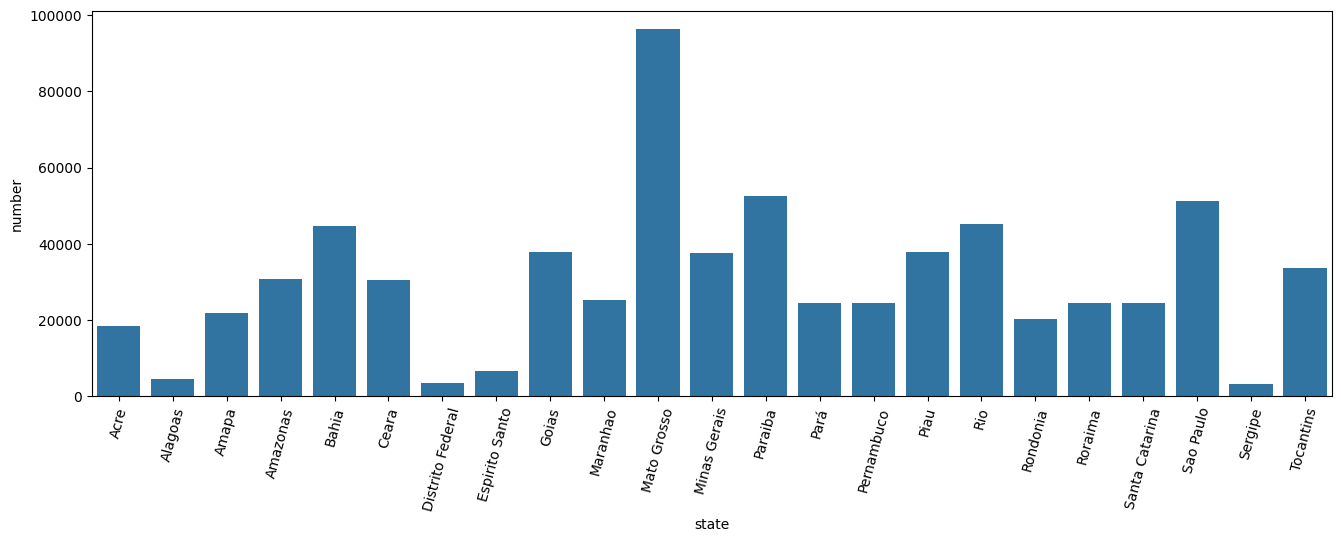

In [38]:
plt.figure(figsize=(16,5))
sns.barplot(x='state', y='number', data=dt3)
plt.xticks(rotation=75)
plt.show()

In [39]:
dt.columns

Index(['year', 'state', 'month', 'number', 'date', 'month_new'], dtype='str')

In [43]:
dt[dt['state']=='Amazonas']['number'].sum()

np.float64(30650.129)

In [48]:
dt4=dt[dt['state']=='Amazonas']
dt5=dt4.groupby('year')['number'].sum().reset_index()
dt5

,year,number
0,1998,946.000
1,1999,1061.000
2,2000,853.000
3,2001,1297.000
4,2002,2852.000
5,2003,1524.268
6,2004,2298.207
7,2005,1657.128
8,2006,997.640
9,2007,589.601


<Axes: xlabel='year', ylabel='number'>

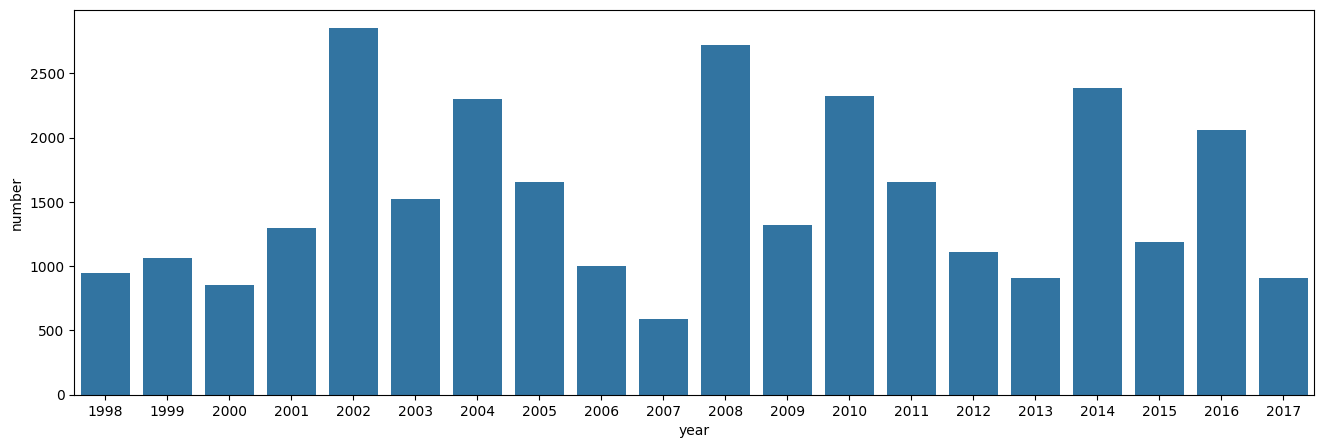

In [50]:
plt.figure(figsize=(16,5))
sns.barplot(x='year', y='number', data=dt5)

In [56]:
dt6=dt[dt['state']=='Amazonas']

In [60]:
day=dt6.groupby(dt6['date'].dt.dayofweek).sum(numeric_only=True).number

import calendar

day.index = [calendar.day_name[x] for x in range(0,7)]
day= day.reset_index()

In [61]:
day

,index,number
0,Monday,1886.601
1,Tuesday,6474.217
2,Wednesday,3910.177
3,Thursday,5754.802
4,Friday,5446.480
5,Saturday,4162.666
6,Sunday,3015.186


<Axes: xlabel='index', ylabel='number'>

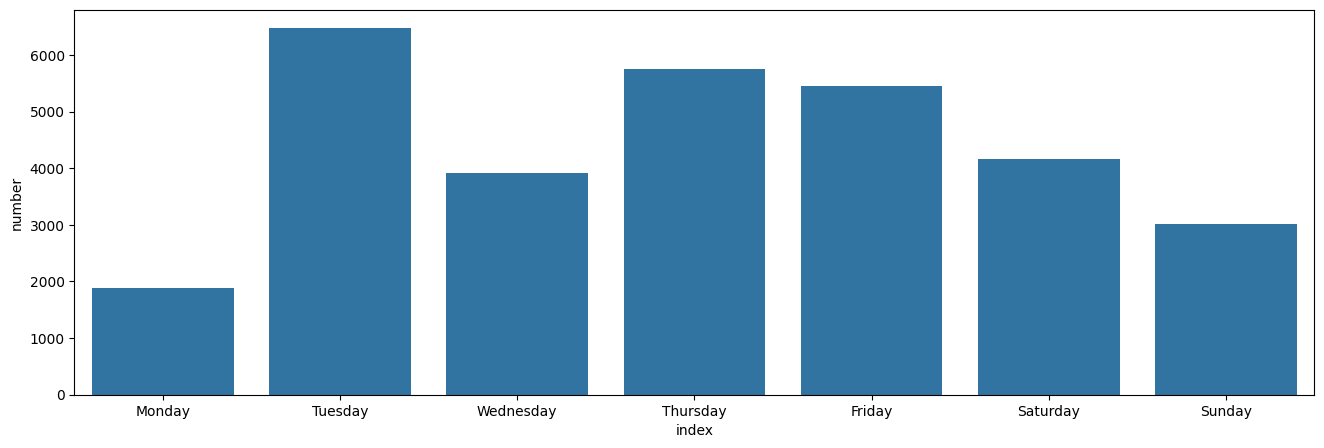

In [62]:
plt.figure(figsize=(16,5))
sns.barplot(x="index",y="number",data=day)

In [64]:
fire = dt[dt['year']==2015].groupby('month_new')['number'].sum().reset_index()
fire

,month_new,number
0,april,2573.000
1,august,4363.125
2,dec,4088.522
3,feb,2309.000
4,jan,4635.000
5,july,4364.392
6,jun,3260.552
7,march,2202.000
8,may,2384.000
9,nov,4034.518


<Axes: xlabel='month_new', ylabel='number'>

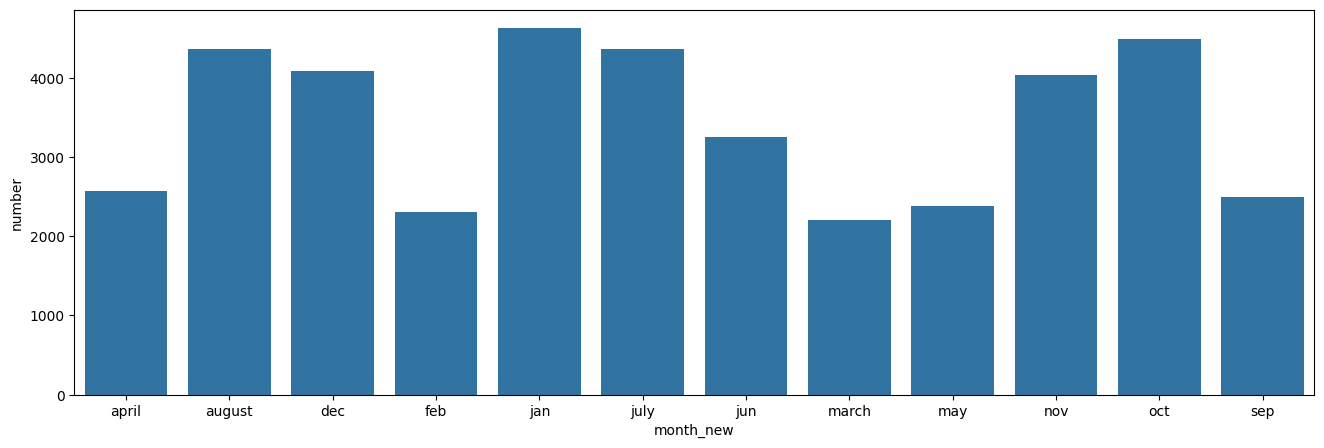

In [65]:
plt.figure(figsize=(16,5))
sns.barplot(x="month_new",y="number",data=fire)

In [67]:
dt8= dt.groupby('state')['number'].mean().sort_values(ascending=False).reset_index()
dt8

,state,number
0,Sao Paulo,213.896226
1,Mato Grosso,203.479975
2,Bahia,187.222703
3,Piau,158.174674
4,Goias,157.721841
5,Minas Gerais,156.800243
6,Tocantins,141.037176
7,Amazonas,128.243218
8,Ceara,127.314071
9,Paraiba,111.073979


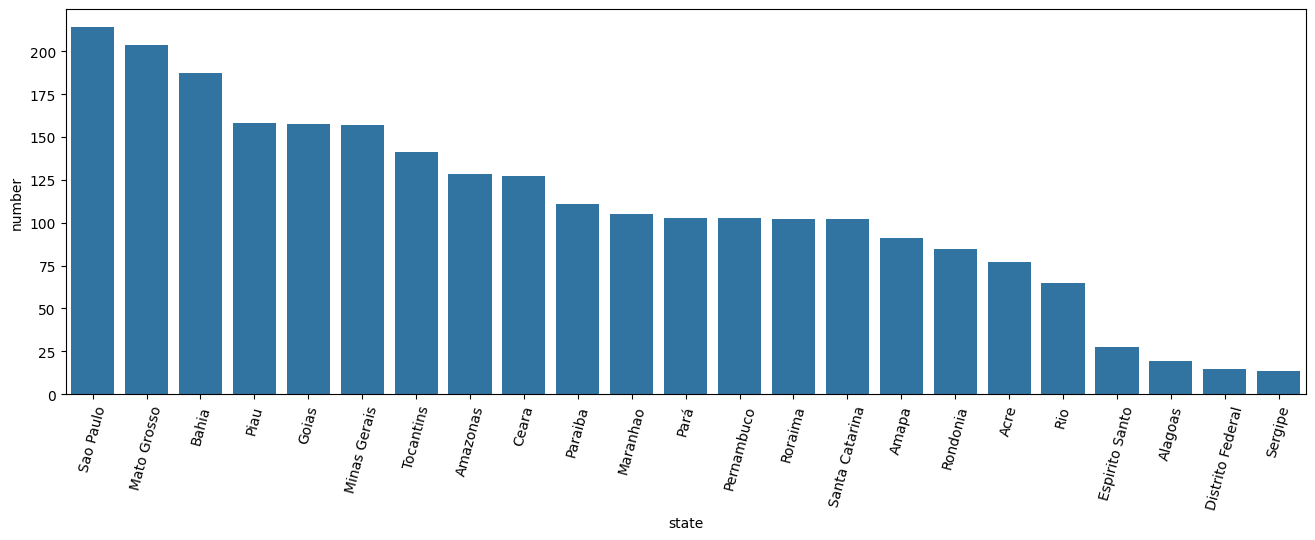

In [68]:
plt.figure(figsize=(16,5))
sns.barplot(x="state",y="number",data=dt8)
plt.xticks(rotation=75)
plt.show()

In [69]:
dt[dt['month_new']=="dec"]['state'].unique()

<StringArray>
[            'Acre',          'Alagoas',            'Amapa',
         'Amazonas',            'Bahia',            'Ceara',
 'Distrito Federal',   'Espirito Santo',            'Goias',
         'Maranhao',      'Mato Grosso',     'Minas Gerais',
             'Pará',          'Paraiba',       'Pernambuco',
             'Piau',              'Rio',         'Rondonia',
          'Roraima',   'Santa Catarina',        'Sao Paulo',
          'Sergipe',        'Tocantins']
Length: 23, dtype: str